# Aula — Desocupação por sexo e trabalho de cuidados
**Python · pandas · merge · matplotlib**

Objetivo: abrir as duas Tabelas 5, comparar a composição da desocupação por sexo em **2012 T1 e 2026 T1** e cruzar as 27 UFs com as horas semanais de cuidados e afazeres domésticos da **Tabela 1.1.1 do IBGE, 2022**.

### Como usar
No Google Colab ou Jupyter, execute as células de cima para baixo. Os três arquivos originais estão incorporados e serão extraídos para `dados_aula`, sem substituir arquivos existentes. Não é necessário enviá-los novamente. As tabelas finais serão salvas em `resultados_aula`.

**Leitura dos indicadores:** os CSVs informam percentuais de homens e mulheres **entre as pessoas desocupadas**, não taxas de desocupação de cada sexo. Há apenas dois períodos: não é possível reconstruir uma série anual de 2013 a 2025. O rótulo 2026 é mantido conforme o arquivo fornecido, sem validação externa de sua procedência.

A referência à tabela da Aula 2 é tratada aqui como o PDF enviado, Tabela 1.1.1. Se houver outra tabela da Aula 2, ela precisa ser fornecida para um cruzamento adicional.

In [1]:
# Execute esta linha apenas se faltar alguma biblioteca (retire o #).
# %pip install pandas numpy matplotlib pdfplumber

from pathlib import Path
import base64
import re
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pdfplumber
from IPython.display import display

pd.set_option('display.max_columns', 16)
pd.set_option('display.precision', 2)
plt.rcParams.update({'figure.figsize': (11, 5), 'axes.spines.top': False,
                     'axes.spines.right': False})

## 1. Preparar os arquivos
A célula abaixo contém cópias exatas dos anexos codificadas em Base64 (apenas uma forma de armazenar bytes dentro do notebook). Ela não faz downloads. Você pode recolher essa célula depois de executá-la.

In [2]:
ARQUIVOS_ORIGINAIS = {'Tabela 1.1.1.pdf': '...', 'Tabela5-sem_emprego_2012.csv': '77u/U2lnbGE7Q8OzZGlnbztFc3RhZG87RGVzb2N1cGFkb3MgLSBob21lbnMgKDIwMTIgVDEpO0Rlc29jdXBhZG9zIC0gbXVsaGVyZXMgKDIwMTIgVDEpDQpBQzsxMjtBY3JlOzQ1LDM7NTQsNw0KQUw7Mjc7QWxhZ29hczs0NCw3OzU1LDMNCkFNOzEzO0FtYXpvbmFzOzQ3LDU7NTIsNQ0KQVA7MTY7QW1hcMOhOzQ4LDE7NTEsOQ0KQkE7Mjk7QmFoaWE7NDMsODs1NiwyDQpDRTsyMztDZWFyw6E7NTEsMTs0OCw5DQpERjs1MztEaXN0cml0byBGZWRlcmFsOzQxOzU5DQpFUzszMjtFc3DDrXJpdG8gU2FudG87NDYsNDs1Myw2DQpHTzs1MjtHb2nDoXM7NDE7NTkNCk1BOzIxO01hcmFuaMOjbzs0NywyOzUyLDgNCk1HOzMxO01pbmFzIEdlcmFpczs0MywxOzU2LDkNCk1TOzUwO01hdG8gR3Jvc3NvIGRvIFN1bDs0NywyOzUyLDgNCk1UOzUxO01hdG8gR3Jvc3NvOzQ0LDE7NTUsOQ0KUEE7MTU7UGFyw6E7NDMsMjs1Niw4DQpQQjsyNTtQYXJhw61iYTs0NCw0OzU1LDYNClBFOzI2O1Blcm5hbWJ1Y287NDMsOTs1NiwxDQpQSTsyMjtQaWF1w607NTEsMjs0OCw4DQpQUjs0MTtQYXJhbsOhOzQwLDM7NTksNw0KUko7MzM7UmlvIGRlIEphbmVpcm87NDQsMjs1NSw4DQpSTjsyNDtSaW8gR3JhbmRlIGRvIE5vcnRlOzUxOzQ5DQpSTzsxMTtSb25kw7RuaWE7NDMsNDs1Niw2DQpSUjsxNDtSb3JhaW1hOzQxLDg7NTgsMg0KUlM7NDM7UmlvIEdyYW5kZSBkbyBTdWw7NDIsODs1NywyDQpTQzs0MjtTYW50YSBDYXRhcmluYTs0Miw3OzU3LDMNClNFOzI4O1NlcmdpcGU7NDYsNTs1Myw1DQpTUDszNTtTw6NvIFBhdWxvOzQ1LDQ7NTQsNg0KVE87MTc7VG9jYW50aW5zOzU1LDM7NDQsNw0K', 'Tabela5-sem_emprego_2026.csv': '77u/U2lnbGE7Q8OzZGlnbztFc3RhZG87RGVzb2N1cGFkb3MgLSBob21lbnMgKDIwMjYgVDEpO0Rlc29jdXBhZG9zIC0gbXVsaGVyZXMgKDIwMjYgVDEpDQpBQzsxMjtBY3JlOzUzLDI7NDYsOA0KQUw7Mjc7QWxhZ29hczs1MCw3OzQ5LDMNCkFNOzEzO0FtYXpvbmFzOzQ2LDg7NTMsMg0KQVA7MTY7QW1hcMOhOzUxLDE7NDgsOQ0KQkE7Mjk7QmFoaWE7NDQsNzs1NSwzDQpDRTsyMztDZWFyw6E7NTIsNzs0NywzDQpERjs1MztEaXN0cml0byBGZWRlcmFsOzQ3LDk7NTIsMQ0KRVM7MzI7RXNww61yaXRvIFNhbnRvOzQ3LDU7NTIsNQ0KR087NTI7R29pw6FzOzQ3LDU7NTIsNQ0KTUE7MjE7TWFyYW5ow6NvOzQ5LDE7NTAsOQ0KTUc7MzE7TWluYXMgR2VyYWlzOzQ4LDY7NTEsNA0KTVM7NTA7TWF0byBHcm9zc28gZG8gU3VsOzQ1LDM7NTQsNw0KTVQ7NTE7TWF0byBHcm9zc287NDIsODs1NywyDQpQQTsxNTtQYXLDoTs0OCwzOzUxLDcNClBCOzI1O1BhcmHDrWJhOzQ4LDk7NTEsMQ0KUEU7MjY7UGVybmFtYnVjbzs0OCw3OzUxLDMNClBJOzIyO1BpYXXDrTs1NSwxOzQ0LDkNClBSOzQxO1BhcmFuw6E7NDYsMzs1Myw3DQpSSjszMztSaW8gZGUgSmFuZWlybzs0NSw0OzU0LDYNClJOOzI0O1JpbyBHcmFuZGUgZG8gTm9ydGU7NDgsMjs1MSw4DQpSTzsxMTtSb25kw7RuaWE7MzM7NjcNClJSOzE0O1JvcmFpbWE7NDMsNDs1Niw2DQpSUzs0MztSaW8gR3JhbmRlIGRvIFN1bDs0Nyw0OzUyLDYNClNDOzQyO1NhbnRhIENhdGFyaW5hOzQ0LDY7NTUsNA0KU0U7Mjg7U2VyZ2lwZTs0MCwzOzU5LDcNClNQOzM1O1PDo28gUGF1bG87NDYsMjs1Myw4DQpUTzsxNztUb2NhbnRpbnM7NDYsMjs1Myw4DQo='}

PASTA = Path('dados_aula')
PASTA.mkdir(exist_ok=True)
for nome, conteudo in ARQUIVOS_ORIGINAIS.items():
    destino = PASTA / nome
    if not destino.exists():
        destino.write_bytes(base64.b64decode(conteudo))
print('Arquivos disponíveis:', sorted(p.name for p in PASTA.iterdir()))

Arquivos disponíveis: ['Tabela 1.1.1.pdf', 'Tabela5-sem_emprego_2012.csv', 'Tabela5-sem_emprego_2026.csv']


## 2. Abrir as duas Tabelas 5
`sep=';'` indica o separador; `decimal=','` reconhece a vírgula decimal; `utf-8-sig` remove a marca de codificação do início do arquivo. As chaves da junção são `Sigla`, `Código` e `Estado`.

In [3]:
CHAVES = ['Sigla', 'Código', 'Estado']

def abrir_tabela5(ano):
    tabela = pd.read_csv(PASTA / f'Tabela5-sem_emprego_{ano}.csv',
                        sep=';', decimal=',', encoding='utf-8-sig')
    tabela = tabela.dropna(axis=1, how='all')
    tabela.columns = tabela.columns.str.strip()
    for coluna in ['Sigla', 'Estado']:
        tabela[coluna] = tabela[coluna].str.strip()
    tabela['Código'] = pd.to_numeric(tabela['Código'], errors='raise').astype(int)
    tabela = tabela.rename(columns={
        f'Desocupados - homens ({ano} T1)': f'homens_{ano}',
        f'Desocupados - mulheres ({ano} T1)': f'mulheres_{ano}'})
    medidas = [f'homens_{ano}', f'mulheres_{ano}']
    assert len(tabela) == 27 and tabela['Sigla'].is_unique
    assert not tabela[CHAVES + medidas].isna().any().any()
    assert tabela[medidas].ge(0).all().all() and tabela[medidas].le(100).all().all()
    assert np.allclose(tabela[medidas].sum(axis=1), 100, atol=0.11)
    return tabela

t2012 = abrir_tabela5(2012)
t2026 = abrir_tabela5(2026)
display(t2012.head(), t2026.head())

,Sigla,Código,Estado,homens_2012,mulheres_2012
0,AC,12,Acre,45.3,54.7
1,AL,27,Alagoas,44.7,55.3
2,AM,13,Amazonas,47.5,52.5
3,AP,16,Amapá,48.1,51.9
4,BA,29,Bahia,43.8,56.2


,Sigla,Código,Estado,homens_2026,mulheres_2026
0,AC,12,Acre,53.2,46.8
1,AL,27,Alagoas,50.7,49.3
2,AM,13,Amazonas,46.8,53.2
3,AP,16,Amapá,51.1,48.9
4,BA,29,Bahia,44.7,55.3


## 3. Juntar as tabelas com `merge`
`inner` mantém as chaves presentes nas duas tabelas. Antes disso, uma junção `outer` verifica se alguma UF seria perdida. `validate='one_to_one'` impede a multiplicação de linhas por chaves duplicadas.

In [4]:
conferencia = t2012[CHAVES].merge(t2026[CHAVES], on=CHAVES,
                                    how='outer', indicator=True, validate='one_to_one')
assert conferencia['_merge'].eq('both').all(), 'Existem chaves sem correspondência.'
comp = t2012.merge(t2026, on=['Sigla', 'Código', 'Estado'],
                   how='inner', validate='one_to_one')
print(f'Junção concluída: {len(comp)} UFs.')
display(comp)

,Sigla,Código,Estado,homens_2012,mulheres_2012,homens_2026,mulheres_2026
0,AC,12,Acre,45.3,54.7,53.2,46.8
1,AL,27,Alagoas,44.7,55.3,50.7,49.3
2,AM,13,Amazonas,47.5,52.5,46.8,53.2
3,AP,16,Amapá,48.1,51.9,51.1,48.9
4,BA,29,Bahia,43.8,56.2,44.7,55.3
5,CE,23,Ceará,51.1,48.9,52.7,47.3
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5
8,GO,52,Goiás,41.0,59.0,47.5,52.5
9,MA,21,Maranhão,47.2,52.8,49.1,50.9


Junção concluída: 27 UFs.


## 4. Comparar os períodos
A diferença é medida em **pontos percentuais (p.p.)**: participação de 2026 menos participação de 2012. Um valor negativo para mulheres significa menor participação feminina no total de desocupados; isoladamente, não demonstra redução do número de mulheres desocupadas.

In [5]:
for sexo in ['homens', 'mulheres']:
    comp[f'variacao_{sexo}_pp'] = (comp[f'{sexo}_2026'] - comp[f'{sexo}_2012']).round(2)
for ano in [2012, 2026]:
    comp[f'diferenca_mulheres_homens_{ano}_pp'] = (comp[f'mulheres_{ano}'] - comp[f'homens_{ano}']).round(2)
ranking = comp.sort_values('variacao_mulheres_pp', ascending=False)
display(ranking[['Sigla', 'Estado', 'mulheres_2012', 'mulheres_2026', 'variacao_mulheres_pp']])
maior = ranking.iloc[0]
menor = ranking.iloc[-1]
print(f"Maior aumento da participação feminina: {maior['Estado']} ({maior['variacao_mulheres_pp']:+.1f} p.p.).")
print(f"Maior redução da participação feminina: {menor['Estado']} ({menor['variacao_mulheres_pp']:+.1f} p.p.).")

,Sigla,Estado,mulheres_2012,mulheres_2026,variacao_mulheres_pp
20,RO,Rondônia,56.6,67.0,10.4
26,TO,Tocantins,44.7,53.8,9.1
24,SE,Sergipe,53.5,59.7,6.2
19,RN,Rio Grande do Norte,49.0,51.8,2.8
11,MS,Mato Grosso do Sul,52.8,54.7,1.9
12,MT,Mato Grosso,55.9,57.2,1.3
2,AM,Amazonas,52.5,53.2,0.7
25,SP,São Paulo,54.6,53.8,-0.8
4,BA,Bahia,56.2,55.3,-0.9
7,ES,Espírito Santo,53.6,52.5,-1.1


Maior aumento da participação feminina: Rondônia (+10.4 p.p.).
Maior redução da participação feminina: Acre (-7.9 p.p.).


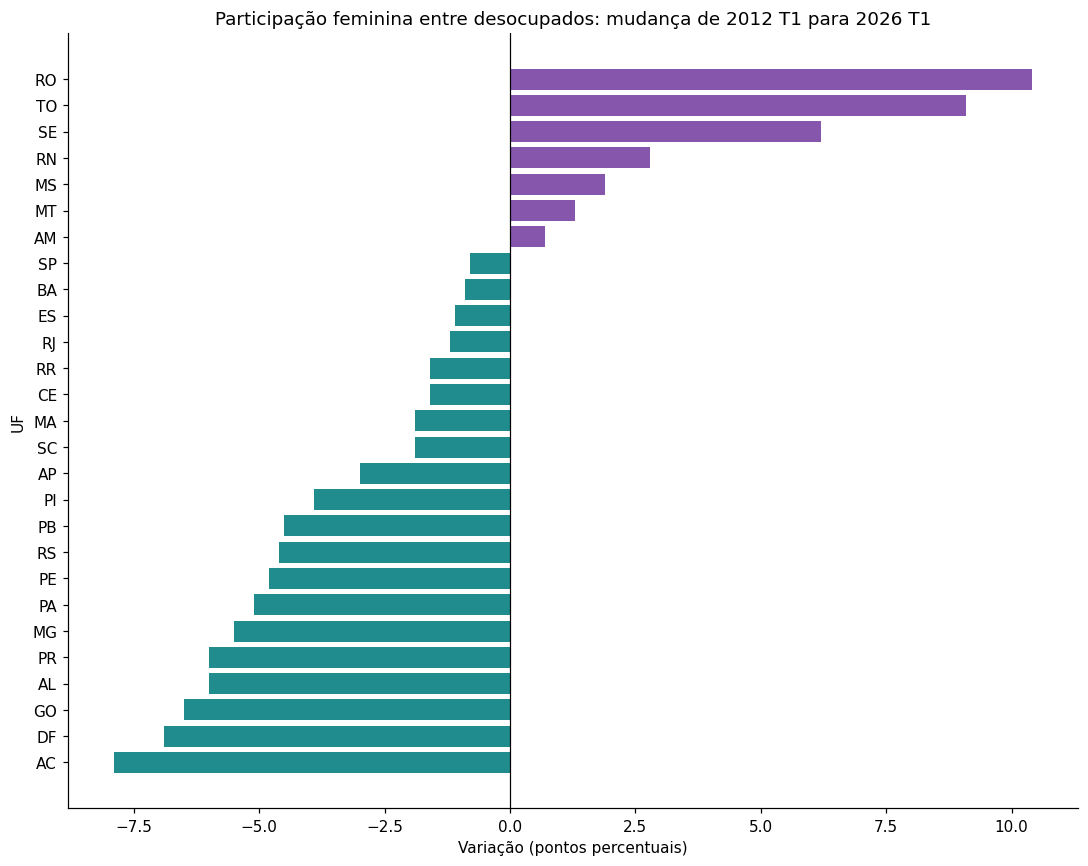

In [6]:
grafico = comp.sort_values('variacao_mulheres_pp')
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(grafico['Sigla'], grafico['variacao_mulheres_pp'],
        color=np.where(grafico['variacao_mulheres_pp'] >= 0, '#8656ad', '#218c8d'))
ax.axvline(0, color='black', linewidth=0.8)
ax.set(title='Participação feminina entre desocupados: mudança de 2012 T1 para 2026 T1',
       xlabel='Variação (pontos percentuais)', ylabel='UF')
plt.tight_layout()
plt.show()

## 5. Abrir o PDF da Tabela 1.1.1 — 2022
As páginas **1 e 2** são metades horizontais da mesma tabela: a primeira contém os nomes das localidades e quatro medidas, e a segunda continua com três medidas na mesma ordem. As páginas seguintes incluem coeficientes de variação e outros anos, que não serão misturados às horas de 2022.

O PDF apresenta total geral e recortes por **sexo e cor ou raça**. Não fornece a média geral de cada sexo nesse quadro. Portanto, não calcularemos a média simples entre brancos e pretos/pardos, pois faltam os pesos populacionais.

Fonte: IBGE, PNAD Contínua, 2022, acumulado de quintas visitas. Pessoas de 14 anos ou mais que realizaram cuidados e/ou afazeres na semana de referência, excluídas aquelas sem declaração das horas.

In [7]:
def extrair_horas_2022(caminho):
    with pdfplumber.open(caminho) as pdf:
        textos = [pdf.pages[i].extract_text() for i in [0, 1]]
    assert all('2022' in texto for texto in textos)
    esquerda, direita = [], []
    for linha in textos[0].splitlines():
        numeros = re.findall(r'\d+,\d+', linha)
        if len(numeros) == 4:
            local = re.split(r'\s+-\s+', linha, maxsplit=1)[0].strip()
            esquerda.append([local] + [float(v.replace(',', '.')) for v in numeros])
    for linha in textos[1].splitlines():
        numeros = re.findall(r'\d+,\d+', linha)
        if len(numeros) == 3:
            direita.append([float(v.replace(',', '.')) for v in numeros])
    # 1 Brasil + 5 regiões + 27 UFs; ambas as metades devem ter as mesmas linhas.
    assert len(esquerda) == len(direita) == 33, 'Confira o layout do PDF.'
    colunas = ['Estado', 'horas_total_2022', 'horas_total_branca_2022',
               'horas_total_preta_parda_2022', 'horas_homens_branca_2022',
               'horas_homens_preta_parda_2022', 'horas_mulheres_branca_2022',
               'horas_mulheres_preta_parda_2022']
    return pd.DataFrame([a + b for a, b in zip(esquerda, direita)], columns=colunas)

horas = extrair_horas_2022(PASTA / 'Tabela 1.1.1.pdf')
assert horas['Estado'].is_unique
assert horas.loc[horas['Estado'].eq('Brasil'), 'horas_total_2022'].iloc[0] == 17.0
display(horas.head(9))

,Estado,horas_total_2022,horas_total_branca_2022,horas_total_preta_parda_2022,horas_homens_branca_2022,horas_homens_preta_parda_2022,horas_mulheres_branca_2022,horas_mulheres_preta_parda_2022
0,Brasil,17.0,16.5,17.3,11.7,11.7,20.4,22.0
1,Norte,16.2,15.9,16.3,11.6,11.5,19.3,20.5
2,Rondônia,17.0,16.7,17.1,12.1,12.5,20.4,21.1
3,Acre,13.6,13.8,13.5,10.8,9.7,16.1,16.7
4,Amazonas,16.8,16.0,17.0,12.2,12.8,18.8,20.7
5,Roraima,13.6,13.7,13.6,10.8,10.5,16.1,16.6
6,Pará,16.5,16.2,16.6,11.5,11.0,19.8,21.6
7,Amapá,13.6,14.4,13.4,11.1,10.7,16.6,15.9
8,Tocantins,15.8,15.7,15.8,10.7,11.7,19.7,19.6


## 6. Cruzar desocupação e horas de cuidados por UF
Normalizamos acentos, maiúsculas e espaços para evitar falhas de correspondência. Brasil e grandes regiões ficam fora da junção porque as Tabelas 5 contêm apenas UFs. O `left merge` preserva todas as UFs e permite conferir eventuais ausências.

In [8]:
def normalizar_nome(nome):
    texto = unicodedata.normalize('NFKD', nome)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    return ' '.join(texto.upper().split())

comp['chave_uf'] = comp['Estado'].map(normalizar_nome)
horas['chave_uf'] = horas['Estado'].map(normalizar_nome)
base = comp.merge(horas.drop(columns='Estado'), on='chave_uf', how='left',
                  validate='one_to_one', indicator=True)
assert len(base) == 27 and base['_merge'].eq('both').all()
base = base.drop(columns=['_merge', 'chave_uf'])
for grupo in ['branca', 'preta_parda']:
    base[f'diferenca_horas_{grupo}_2022'] = (
        base[f'horas_mulheres_{grupo}_2022'] - base[f'horas_homens_{grupo}_2022']).round(2)
display(base[['Estado', 'mulheres_2012', 'mulheres_2026', 'horas_total_2022',
              'diferenca_horas_branca_2022', 'diferenca_horas_preta_parda_2022']])

,Estado,mulheres_2012,mulheres_2026,horas_total_2022,diferenca_horas_branca_2022,diferenca_horas_preta_parda_2022
0,Acre,54.7,46.8,13.6,5.3,7.0
1,Alagoas,55.3,49.3,20.2,12.0,12.5
2,Amazonas,52.5,53.2,16.8,6.6,7.9
3,Amapá,51.9,48.9,13.6,5.5,5.2
4,Bahia,56.2,55.3,17.8,12.0,12.2
5,Ceará,48.9,47.3,19.5,10.8,12.2
6,Distrito Federal,59.0,52.1,15.1,6.3,8.8
7,Espírito Santo,53.6,52.5,17.1,8.7,10.2
8,Goiás,59.0,52.5,15.2,7.8,9.1
9,Maranhão,52.8,50.9,16.7,8.2,9.3


## 7. Visualizar as horas por sexo e cor ou raça
Escolha a sigla de uma UF abaixo. As diferenças são expressas em horas semanais.

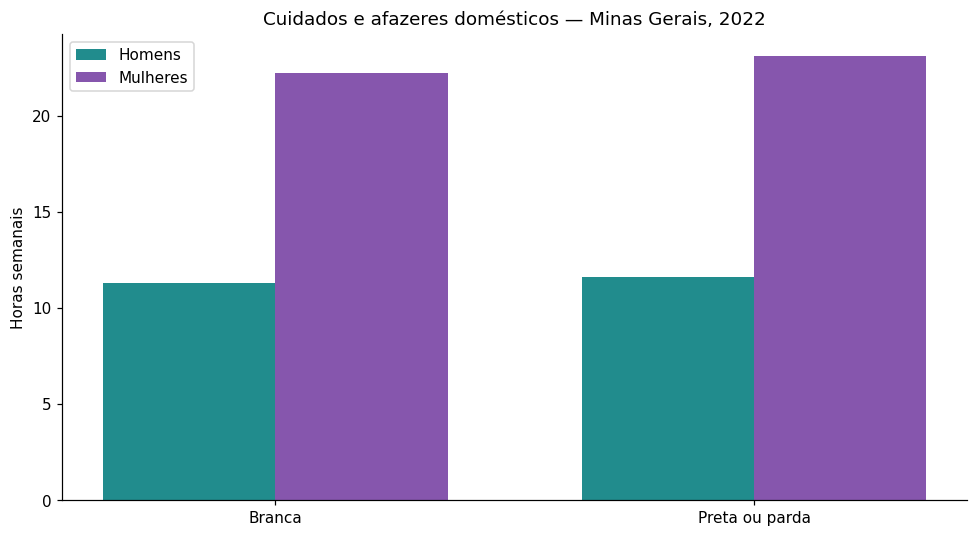

In [9]:
UF = 'MG'  # Altere, por exemplo, para SP, BA ou AC.
linha = base.set_index('Sigla').loc[UF]
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(2)
ax.bar(x - 0.18, [linha['horas_homens_branca_2022'], linha['horas_homens_preta_parda_2022']],
       width=0.36, label='Homens', color='#218c8d')
ax.bar(x + 0.18, [linha['horas_mulheres_branca_2022'], linha['horas_mulheres_preta_parda_2022']],
       width=0.36, label='Mulheres', color='#8656ad')
ax.set_xticks(x, ['Branca', 'Preta ou parda'])
ax.set(ylabel='Horas semanais', title=f"Cuidados e afazeres domésticos — {linha['Estado']}, 2022")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Explorar a associação entre os indicadores
Os gráficos abaixo cruzam a participação feminina entre desocupados de cada período com as horas das mulheres pretas ou pardas em 2022. Cada ponto é uma UF. O recorte de cor ou raça das horas **não existe nos CSVs de desocupação**; portanto, não se trata da desocupação específica de mulheres pretas ou pardas.

A correlação é descritiva, entre UFs, sem ponderação populacional. Os períodos são diferentes e não há controle por outros fatores: ela não demonstra causalidade nem descreve uma relação individual.

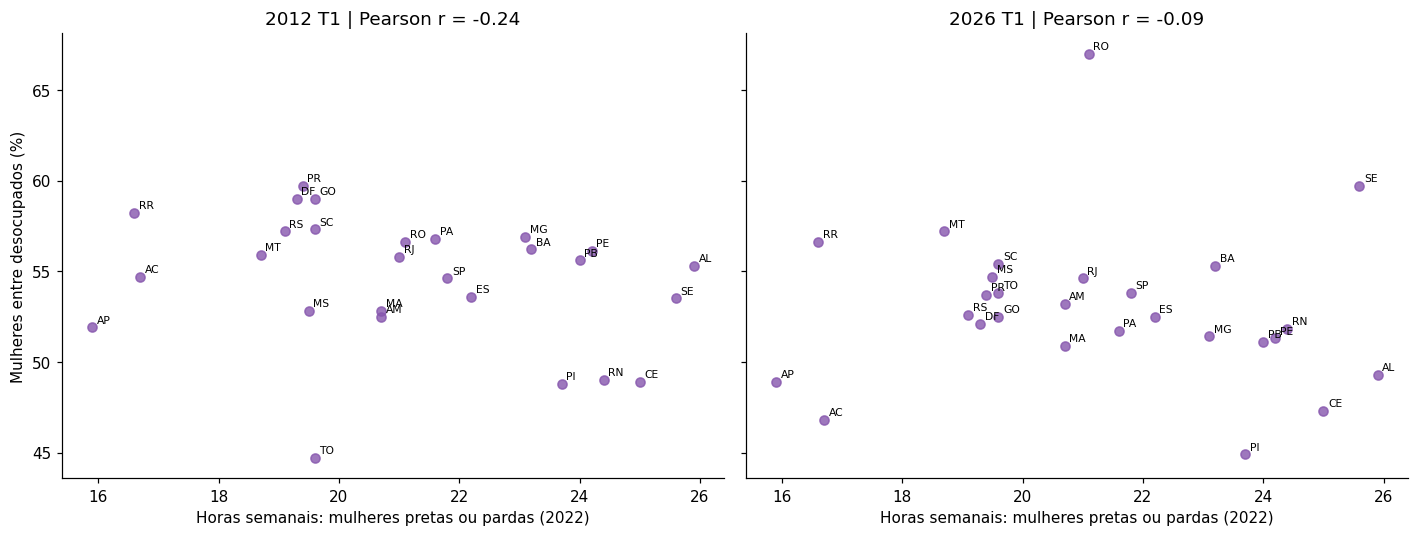

,mulheres_2012,mulheres_2026,variacao_mulheres_pp,horas_mulheres_branca_2022,horas_mulheres_preta_parda_2022
mulheres_2012,1.00,0.31,-0.48,-0.23,-0.24
mulheres_2026,0.31,1.00,0.68,-0.08,-0.09
variacao_mulheres_pp,-0.48,0.68,1.00,0.10,0.10
horas_mulheres_branca_2022,-0.23,-0.08,0.10,1.00,0.94
horas_mulheres_preta_parda_2022,-0.24,-0.09,0.10,0.94,1.00


In [10]:
coluna_horas = 'horas_mulheres_preta_parda_2022'
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, ano in zip(axes, [2012, 2026]):
    ax.scatter(base[coluna_horas], base[f'mulheres_{ano}'], color='#8656ad', alpha=0.8)
    for _, ponto in base.iterrows():
        ax.annotate(ponto['Sigla'], (ponto[coluna_horas], ponto[f'mulheres_{ano}']),
                    xytext=(3, 3), textcoords='offset points', fontsize=7)
    r = base[coluna_horas].corr(base[f'mulheres_{ano}'])
    ax.set(title=f'{ano} T1 | Pearson r = {r:.2f}',
           xlabel='Horas semanais: mulheres pretas ou pardas (2022)')
axes[0].set_ylabel('Mulheres entre desocupados (%)')
plt.tight_layout()
plt.show()
display(base[['mulheres_2012', 'mulheres_2026', 'variacao_mulheres_pp',
              'horas_mulheres_branca_2022', coluna_horas]].corr().round(3))

## 9. Salvar os resultados
Os CSVs usam ponto e vírgula, vírgula decimal e codificação compatível com Excel. No Colab, abra a pasta `resultados_aula` na lateral para baixá-los.

In [11]:
SAIDA = Path('resultados_aula')
SAIDA.mkdir(exist_ok=True)
comp.drop(columns='chave_uf').to_csv(SAIDA / 'comparacao_2012_2026.csv', index=False,
                                    sep=';', decimal=',', encoding='utf-8-sig')
horas.drop(columns='chave_uf').to_csv(SAIDA / 'horas_ibge_2022.csv', index=False,
                                     sep=';', decimal=',', encoding='utf-8-sig')
base.to_csv(SAIDA / 'base_cruzada.csv', index=False, sep=';', decimal=',', encoding='utf-8-sig')
print('Concluído: 27 UFs cruzadas, sem ausências. Resultados em:', SAIDA.resolve())

Concluído: 27 UFs cruzadas, sem ausências. Resultados em: /workspace/scratch/07cc48775c46/output/resultados_aula


## 10. Questões para a atividade
1. Qual UF apresentou a maior mudança na participação feminina entre os desocupados?
2. Em quais UFs as mulheres eram maioria entre os desocupados em cada período?
3. Qual UF teve a maior diferença de horas entre mulheres e homens no grupo preto ou pardo em 2022?
4. Por que a participação feminina entre desocupados não equivale à taxa de desocupação das mulheres?
5. Por que o cruzamento com as horas de 2022 não prova que o trabalho doméstico causa desocupação?

**Conclusão metodológica:** `merge` permite combinar fontes pela geografia, preservando o ano, a unidade de medida e o universo de cada indicador. As comparações deste notebook são entre os dois períodos disponíveis, e o cruzamento com 2022 é exploratório.